RMSE : 0.2341
MAE  : 0.1761
R²   : 0.8447

Bucket Accuracy per Kategori:
              sum  count      mean
bucket_true                       
high          915   1580  0.579114
low          2981   3306  0.901694
medium       4446   5298  0.839185


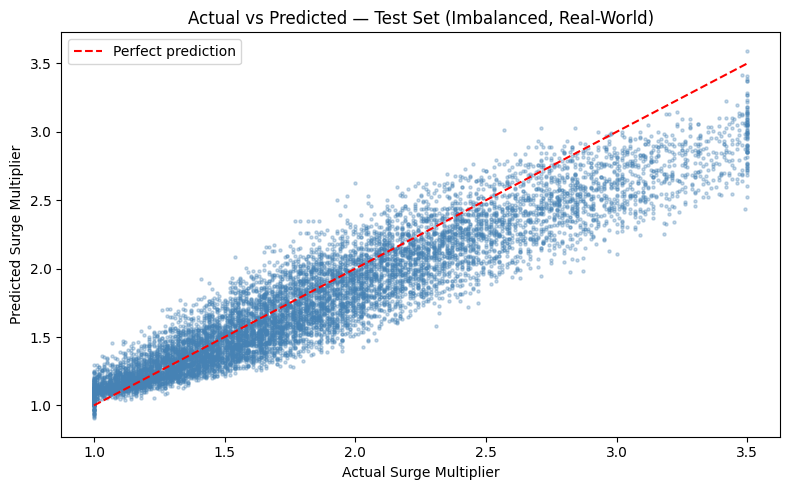

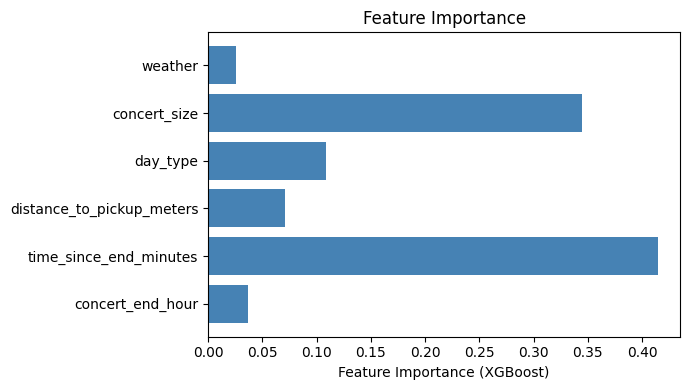


Sanity Check Inferensi:
  Case Low: surge = 1.1
  Case Mid: surge = 2.18
  Case High: surge = 3.24


In [4]:
import joblib, json
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# Load artifacts
model   = joblib.load("../models/surge_predictor.pkl")
encoder = joblib.load("../models/encoder.pkl")
scaler  = joblib.load("../models/scaler.pkl")

# Load test set (data murni, imbalanced — kondisi dunia nyata)
test = pd.read_csv("../data/test/test.csv")

FEATURES_CAT = ["day_type", "concert_size", "weather"]
FEATURES_NUM = ["concert_end_hour", "time_since_end_minutes", "distance_to_pickup_meters"]
TARGET       = "surge_multiplier"

X_cat = encoder.transform(test[FEATURES_CAT])
X_num = scaler.transform(test[FEATURES_NUM])
X     = np.hstack([X_num, X_cat])
y     = test[TARGET].values

# Prediksi
y_pred = model.predict(X)

# Metrik utama
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
r2   = r2_score(y, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# Bucket accuracy — ini yang paling penting untuk dijelaskan ke Kadiv
def bucket(v):
    if v < 1.5:   return "low"
    elif v <= 2.5: return "medium"
    else:          return "high"

test["bucket_true"] = [bucket(v) for v in y]
test["bucket_pred"] = [bucket(v) for v in y_pred]
test["bucket_correct"] = test["bucket_true"] == test["bucket_pred"]

print("\nBucket Accuracy per Kategori:")
print(test.groupby("bucket_true")["bucket_correct"].agg(["sum","count","mean"]))

# Plot: Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y, y_pred, alpha=0.3, s=5, color="steelblue")
plt.plot([1,3.5],[1,3.5], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Surge Multiplier")
plt.ylabel("Predicted Surge Multiplier")
plt.title("Actual vs Predicted — Test Set (Imbalanced, Real-World)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/actual_vs_predicted.png", dpi=150)
plt.show()

# Feature importance
feat_names = FEATURES_NUM + FEATURES_CAT
importances = model.feature_importances_
plt.figure(figsize=(7,4))
plt.barh(feat_names, importances, color="steelblue")
plt.xlabel("Feature Importance (XGBoost)")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=150)
plt.show()

# Sanity check
print("\nSanity Check Inferensi:")
cases = [
    ("Low",  [20, 80, 120, "weekday", "small",  "clear"]),
    ("Mid",  [22, 30, 380, "weekend", "medium", "cloudy"]),
    ("High", [23,  5, 650, "weekend", "large",  "rain"]),
]
for label, vals in cases:
    num = scaler.transform([vals[:3]])
    cat = encoder.transform([vals[3:]])
    feat = np.hstack([num, cat])
    pred = round(float(model.predict(feat)[0]), 2)
    print(f"  Case {label}: surge = {pred}")